In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
#import normalization library
from sklearn.preprocessing import StandardScaler
#import
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#load the dataset
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')


In [2]:
#Data exploration

print("Dataset shape:", titanic_df.shape)
print("")
#print 1st 5 rows
print(titanic_df.head())
print("")
#print the datatype of each column
print(titanic_df.info())

# print count of the missing values
print("Missing values: ",titanic_df.isnull().sum())
print("")
#print the survived vs unsurvived
print(titanic_df['Survived'].value_counts())

Dataset shape: (891, 12)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   

Text(0.5, 0, 'Fare')

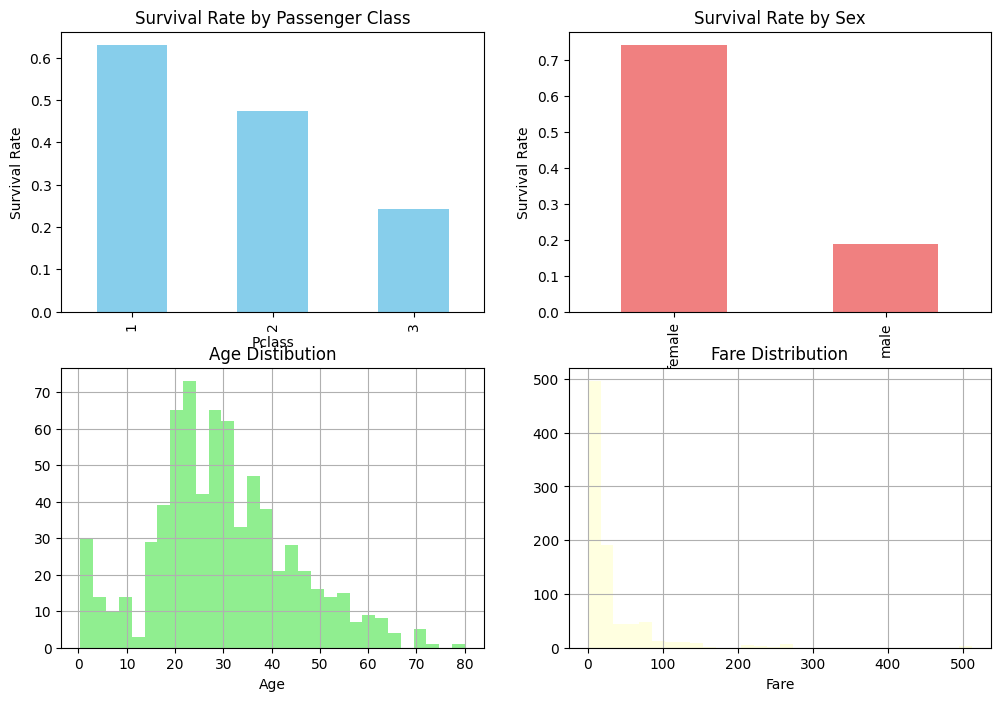

In [3]:
#Data virtualization/Exploratory Data Analysis

#create grid of 4 charts
fig, axes = plt.subplots(2,2, figsize=(12,8))

#survival by class
titanic_df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0,0],color='skyblue')
axes[0,0].set_title('Survival Rate by Passenger Class')
axes[0,0].set_ylabel('Survival Rate')

#survival by sex
titanic_df.groupby('Sex')['Survived'].mean().plot(kind='bar',ax=axes[0,1] ,color='lightcoral')
axes[0,1].set_title('Survival Rate by Sex')
axes[0,1].set_ylabel('Survival Rate')

#age distribution
titanic_df['Age'].hist(bins=30, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Age Distibution')
axes[1,0].set_xlabel('Age')

#fare  distribution
titanic_df['Fare'].hist(bins=30, ax=axes[1,1], color='lightyellow')
axes[1,1].set_title('Fare Distribution')
axes[1,1].set_xlabel('Fare')



In [4]:
#Data preprocessing(Clean)
df = titanic_df.copy()
#replace missing ages with median of all ages
df['Age'].fillna(df['Age'].median(), inplace=True)

#replace missing port info with the most common port(mode)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

# drop unnecessary columns/columns with missing values
df.drop(['Cabin','Ticket','PassengerId','Name'],axis=1,inplace=True)

# encode categorical variables, ML model only understands numbers
df['Sex']= df['Sex'].map({'male':1, 'female':0})
df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})

print("\nProcessed dataset:")
print(df.head())
print('\nFinal missing values:')
print(df.isnull().sum())




Processed dataset:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         0
1         1       1    0  38.0      1      0  71.2833         1
2         1       3    0  26.0      0      0   7.9250         0
3         1       1    0  35.0      1      0  53.1000         0
4         0       3    1  35.0      0      0   8.0500         0

Final missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_9704\2375564169.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_9704\2375564169.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [5]:
#Prepare features and target
X = df.drop('Survived', axis=1)
y = df['Survived']


In [6]:
#split the data
#Stratifying data involves dividing a population into distinct subpopulations, known as strata, based on specific characteristics. This technique is commonly used in stratified sampling, where researchers ensure that each subgroup is represented in the sample, leading to more accurate and reliable results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#training set(80%) - teaches the model how to predict survival
#test data(20%) - checks if model works on new, unseen data

In [7]:
#Standardize features to put everything on the same scale
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
#train model
model = RandomForestClassifier(n_estimators=100,random_state=42, max_depth=10)
model.fit(X_train_scaled, y_train)


RandomForestClassifier(max_depth=10, random_state=42)

In [9]:
#make predictions
y_pred = model.predict(X_test_scaled)

In [10]:
#evaluate model
print("\n"+"="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy:{accuracy_score(y_test,y_pred):.4f}")
print(f"Precision:{precision_score(y_test,y_pred):.4f}")
print(f"Recall: {recall_score(y_test,y_pred):.4f}")
print(f"F1-Score:{f1_score(y_test,y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))



MODEL PERFORMANCE
Accuracy:0.8101
Precision:0.8070
Recall: 0.6667
F1-Score:0.7302

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.90      0.85       110
       Survived       0.81      0.67      0.73        69

       accuracy                           0.81       179
      macro avg       0.81      0.78      0.79       179
   weighted avg       0.81      0.81      0.81       179



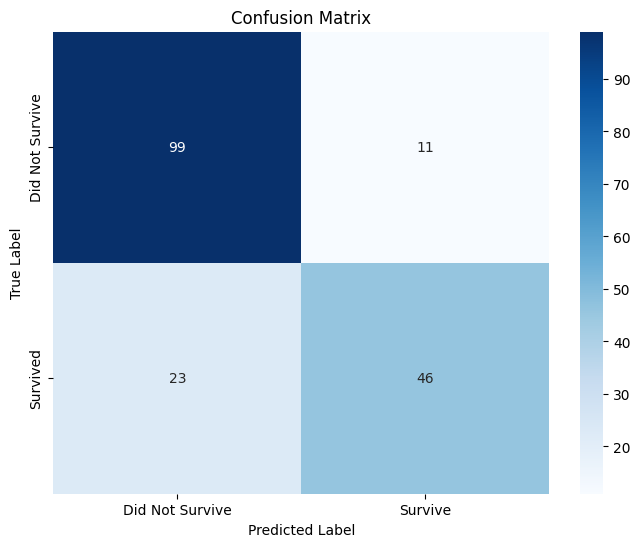

In [11]:
#confusion matrix - table showing how many predictions a model got right and wrong
cm =confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Did Not Survive','Survive'],
            yticklabels=['Did Not Survive','Survived'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_9704\943670449.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance',y='Feature', palette='viridis')


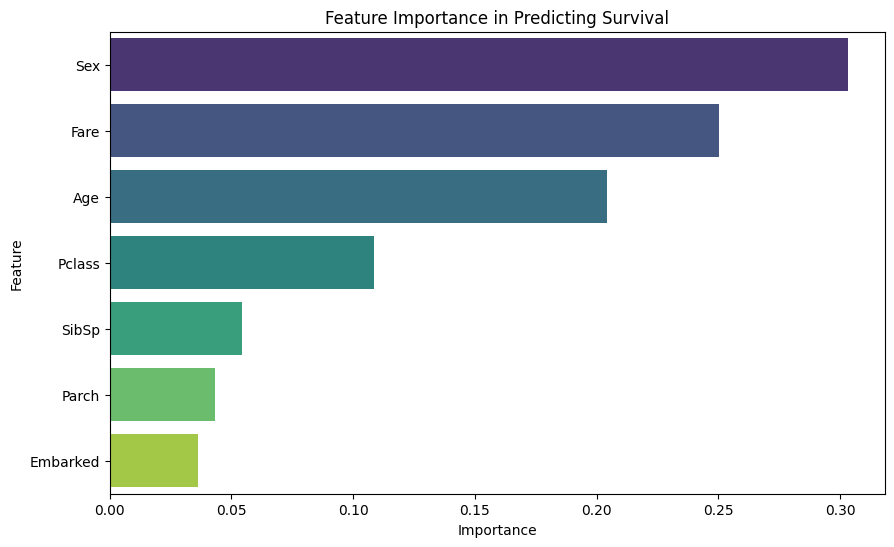


Feature Importance:
    Feature  Importance
1       Sex    0.303257
5      Fare    0.250229
2       Age    0.204239
0    Pclass    0.108516
3     SibSp    0.054316
4     Parch    0.043083
6  Embarked    0.036361


In [12]:
#feature importance - shows most helpful features in making predictions
feature_importance =pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_

}).sort_values('Importance',ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='Importance',y='Feature', palette='viridis')
plt.title('Feature Importance in Predicting Survival')
plt.xlabel('Importance')
plt.show()

print("\nFeature Importance:")
print(feature_importance)

In [13]:
# Manual Predictions on New Passengers
print("\n" + "="*50)
print("MAKING PREDICTIONS ON NEW PASSENGERS")
print("="*50)

# Reminder of what each feature means:
# Pclass: 1=First class, 2=Second class, 3=Third class
# Sex: 1=Male, 0=Female
# Age: Age in years
# SibSp: Number of siblings/spouses aboard
# Parch: Number of parents/children aboard
# Fare: Ticket price in pounds
# Embarked: 0=Southampton, 1=Cherbourg, 2=Queenstown

# Example 1: Young first-class female
passenger_1 = [[1, 0, 20, 1, 0, 72.0, 0]]
pred_1 = model.predict(passenger_1)[0]
prob_1 = model.predict_proba(passenger_1)[0]
print("\nPassenger 1: First-class, Female, Age 20")
print(f"  Prediction: {'SURVIVED ✓' if pred_1 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"  Probability of survival: {prob_1[1]:.2%}")

# Example 2: Older third-class male
passenger_2 = [[3, 1, 55, 0, 0, 8.0, 0]]
pred_2 = model.predict(passenger_2)[0]
prob_2 = model.predict_proba(passenger_2)[0]
print("\nPassenger 2: Third-class, Male, Age 55")
print(f"  Prediction: {'SURVIVED ✓' if pred_2 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"  Probability of survival: {prob_2[1]:.2%}")

# Example 3: Young second-class female
passenger_3 = [[2, 0, 18, 1, 1, 18.0, 0]]
pred_3 = model.predict(passenger_3)[0]
prob_3 = model.predict_proba(passenger_3)[0]
print("\nPassenger 3: Second-class, Female, Age 18, with 1 sibling and 1 parent")
print(f"  Prediction: {'SURVIVED ✓' if pred_3 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"  Probability of survival: {prob_3[1]:.2%}")

# Example 4: Young first-class male
passenger_4 = [[1, 1, 25, 0, 0, 55.0, 0]]
pred_4 = model.predict(passenger_4)[0]
prob_4 = model.predict_proba(passenger_4)[0]
print("\nPassenger 4: First-class, Male, Age 25")
print(f"  Prediction: {'SURVIVED ✓' if pred_4 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"  Probability of survival: {prob_4[1]:.2%}")

#Custom predictions
#Older third class female
passenger_5 = [[3, 0, 40, 0, 0, 8.0, 2]]
pred_5 = model.predict(passenger_5)[0]
prob_5 = model.predict_proba(passenger_5)[0]
print("\nPassenger 5: Third-class, Female, Age 40")
print(f"  Prediction: {'SURVIVED ✓' if pred_5 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"  Probability of survival: {prob_5[1]:.2%}")

#Young second-class male, with 1 sibling
passenger_6 =[[2, 1, 18, 1, 0, 18.0, 0]]
pred_6 = model.predict(passenger_6)[0]
prob_6 = model.predict_proba(passenger_6)[0]
print("\nPassenger 6: Second-class, Male, with 1 sibling, Age 18")
print(f"  Prediction: {'SURVIVED ✓' if pred_6 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"  Probability of survival: {prob_6[1]:.2%}")







MAKING PREDICTIONS ON NEW PASSENGERS

Passenger 1: First-class, Female, Age 20
  Prediction: DID NOT SURVIVE ✗
  Probability of survival: 37.85%

Passenger 2: Third-class, Male, Age 55
  Prediction: SURVIVED ✓
  Probability of survival: 58.25%

Passenger 3: Second-class, Female, Age 18, with 1 sibling and 1 parent
  Prediction: DID NOT SURVIVE ✗
  Probability of survival: 20.67%

Passenger 4: First-class, Male, Age 25
  Prediction: SURVIVED ✓
  Probability of survival: 58.25%

Passenger 5: Third-class, Female, Age 40
  Prediction: DID NOT SURVIVE ✗
  Probability of survival: 34.64%

Passenger 6: Second-class, Male, with 1 sibling, Age 18
  Prediction: DID NOT SURVIVE ✗
  Probability of survival: 37.85%


In [14]:
#Older first-class female
passenger_7=[[3,0,60,0,0,55.0,0]]
pred_7 = model.predict(passenger_7)[0]
prob_7 = model.predict_proba(passenger_7)[0]
print("\nPassenger 7: Third-class, Female, Age 60")
print(f"  Prediction: {'SURVIVED ✓' if pred_7 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"  Probability of survival: {prob_7[1]:.2%}")

#Older third-class male
passenger_8=[[3,1,35,0,0,8.0,0]]
pred_8 = model.predict(passenger_8)[0]
prob_8 = model.predict_proba(passenger_8)[0]
print("\nPassenger 8: Third-class, Male, Age 35")
print(f"  Prediction: {'SURVIVED ✓' if pred_8 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"  Probability of survival: {prob_8[1]:.2%}")


Passenger 7: Third-class, Female, Age 60
  Prediction: SURVIVED ✓
  Probability of survival: 58.25%

Passenger 8: Third-class, Male, Age 35
  Prediction: SURVIVED ✓
  Probability of survival: 58.25%


In [15]:
import pickle

# save model
pickle.dump(model, open('titanic_model.pkl', 'wb'))

# save scaler  (for future predictions)
pickle.dump(scaler, open('titanic_scaler.pkl', 'wb'))

print("Model and scaler saved!")

Model and scaler saved!
